<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day1_DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ============================================================
# ÉTAPE 1A — Imports
# ============================================================
# POURQUOI : on charge toutes les bibliothèques nécessaires avant de commencer.
# COMMENT  : on importe NumPy (calculs), Matplotlib (graphes), TensorFlow (deep learning)
#            et quelques utilitaires sklearn pour l'évaluation finale.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist          # le dataset est inclus dans Keras
from tensorflow.keras.utils import to_categorical    # pour l'encodage one-hot
from tensorflow.keras import layers, models          # pour construire le modèle
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style("whitegrid")

In [15]:
# ============================================================
# ÉTAPE 1B — Charger le dataset MNIST
# ============================================================
# POURQUOI : MNIST contient 70 000 images de chiffres manuscrits (0-9).
#            C'est le "Hello World" du deep learning, parfait pour apprendre.
# COMMENT  : Keras fournit MNIST directement via mnist.load_data().
#            On obtient 4 tableaux : x_train (60k images), y_train (labels),
#            x_test (10k images de test), y_test (labels de test).

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Affichage des formes pour vérifier ce qu'on a chargé
print(f"x_train shape : {x_train.shape}  → 60 000 images de 28x28 pixels")
print(f"y_train shape : {y_train.shape}  → 60 000 labels (chiffres 0-9)")
print(f"x_test shape  : {x_test.shape}   → 10 000 images pour le test")
print(f"y_test shape  : {y_test.shape}   → 10 000 labels de test")

# Note importante : x_train/x_test sont DÉJÀ séparés en train/test
# par Keras → pas besoin de train_test_split !

x_train shape : (60000, 28, 28)  → 60 000 images de 28x28 pixels
y_train shape : (60000,)  → 60 000 labels (chiffres 0-9)
x_test shape  : (10000, 28, 28)   → 10 000 images pour le test
y_test shape  : (10000,)   → 10 000 labels de test


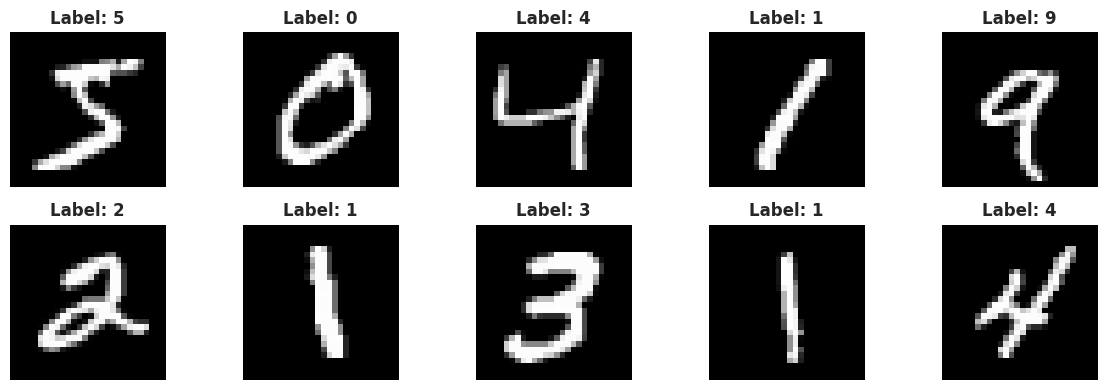

Labels uniques : [0 1 2 3 4 5 6 7 8 9]
Valeurs pixels : min=0, max=255


In [16]:
# ============================================================
# ÉTAPE 1C — Visualiser quelques images
# ============================================================
# POURQUOI : avant de faire du machine learning, il faut TOUJOURS regarder
#            ses données. Cela permet de détecter des bugs évidents
#            (mauvais labels, images corrompues, etc.) avant de gaspiller
#            des heures d'entraînement.
# COMMENT  : on affiche 10 images aléatoires avec leur label associé.

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)              # grille 2 lignes × 5 colonnes
    plt.imshow(x_train[i], cmap="gray") # cmap='gray' pour niveaux de gris
    plt.title(f"Label: {y_train[i]}", fontweight='bold')
    plt.axis("off")                     # cache les axes pour plus de lisibilité
plt.tight_layout()
plt.show()

# Vérification : les chiffres sont entiers entre 0 et 9
print(f"Labels uniques : {np.unique(y_train)}")
print(f"Valeurs pixels : min={x_train.min()}, max={x_train.max()}")
# → Les pixels sont entre 0 (noir) et 255 (blanc)

In [17]:
# ============================================================
# ÉTAPE 1D — Normaliser les pixels (0-255 → 0-1)
# ============================================================
# POURQUOI : les réseaux neuronaux s'entraînent BEAUCOUP MIEUX quand les
#            entrées sont entre 0 et 1.
#            - Grandes valeurs (255) → gradients énormes → instabilité
#            - Petites valeurs (0-1) → gradients stables → convergence rapide
# COMMENT  : on divise simplement par 255 (la valeur max d'un pixel).
#            On convertit aussi en float32 (les entiers ne marchent pas pour
#            la rétropropagation qui calcule des dérivées).

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

print(f"Après normalisation : min={x_train.min():.2f}, max={x_train.max():.2f}")
# → 0.00 et 1.00 maintenant ✅

Après normalisation : min=0.00, max=1.00


In [18]:
# ============================================================
# ÉTAPE 1E — Encoder les labels en one-hot
# ============================================================
# POURQUOI : la sortie du réseau sera un Softmax qui produit 10 probabilités
#            (une par chiffre 0-9). Pour comparer ces probabilités avec la
#            vérité via la categorical_crossentropy, la vérité doit AUSSI
#            être sous forme de vecteur de probabilités → one-hot.
# COMMENT  : on convertit chaque label entier (ex: 3) en vecteur de 10 valeurs
#            avec un 1 à la position du label et des 0 partout ailleurs.
#            Exemple : 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

print(f"Avant : y_train[0] = {y_train[0]}")
print(f"Après : y_train_oh[0] = {y_train_oh[0]}")
print(f"Shape one-hot : {y_train_oh.shape}  → 60 000 vecteurs de taille 10")

Avant : y_train[0] = 5
Après : y_train_oh[0] = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Shape one-hot : (60000, 10)  → 60 000 vecteurs de taille 10


In [19]:
# ============================================================
# ÉTAPE 2 — Construire le réseau neuronal
# ============================================================
# POURQUOI : on définit l'architecture du modèle. Comme c'est un classifieur
#            d'images simple, un réseau "fully connected" (Dense) suffit.
# COMMENT  : on empile les couches avec models.Sequential :
#            1. Flatten     → transforme l'image 2D en vecteur 1D
#            2. Dense(128)  → 1ère couche cachée (apprend des motifs basiques)
#            3. Dense(64)   → 2ème couche cachée (combine en motifs complexes)
#            4. Dense(10)   → couche de sortie : une probabilité par chiffre

model = models.Sequential([
    # Flatten : convertit l'image 28×28 (2D) en vecteur de 784 valeurs (1D)
    # Les couches Dense ne comprennent pas la 2D, elles ont besoin d'un vecteur
    layers.Flatten(input_shape=(28, 28)),

    # 1ère couche cachée : 128 neurones avec activation ReLU
    # ReLU = max(0, x) → fonction simple qui évite le "vanishing gradient"
    # 128 neurones = suffisant pour apprendre la plupart des traits des chiffres
    layers.Dense(128, activation='relu'),

    # 2ème couche cachée : 64 neurones avec ReLU
    # Moins de neurones que la 1ère → "compresse" l'information
    # Ajoute de la profondeur pour apprendre des concepts plus abstraits
    layers.Dense(64, activation='relu'),

    # Couche de sortie : 10 neurones (un par classe 0-9)
    # Softmax transforme les scores bruts en probabilités qui somment à 1
    layers.Dense(10, activation='softmax')
])

# Affichage de l'architecture (nombre de paramètres par couche)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================================
# ÉTAPE 2B — Compiler le modèle
# ============================================================
# POURQUOI : avant l'entraînement, il faut définir 3 choses :
#            - Optimiseur : comment ajuster les poids
#            - Loss : comment mesurer l'erreur
#            - Metric : quelle valeur on suit pour évaluer la performance
# COMMENT  : on utilise les choix standards pour la classification multi-classes :

model.compile(
    # optimizer='adam' : optimiseur adaptatif, ajuste automatiquement le pas
    # d'apprentissage pour chaque poids. C'est LE choix par défaut moderne.
    optimizer='adam',

    # loss='categorical_crossentropy' : mesure la distance entre les
    # probabilités prédites (softmax) et la vérité (one-hot).
    # Obligatoire pour classification multi-classes avec labels one-hot.
    loss='categorical_crossentropy',

    # metrics=['accuracy'] : on suit le % de prédictions correctes
    # pendant l'entraînement (ne sert pas à l'optimisation, juste à l'humain)
    metrics=['accuracy']
)

print("✅ Modèle compilé avec succès")

✅ Modèle compilé avec succès


In [21]:
# ============================================================
# ÉTAPE 3 — Entraîner le modèle
# ============================================================
# POURQUOI : le modèle ajuste ses poids en fonction des données d'entraînement.
#            À chaque epoch, il "voit" tout le dataset et améliore ses prédictions.
# COMMENT  : on appelle model.fit() avec plusieurs paramètres importants :

history = model.fit(
    x_train, y_train_oh,           # données d'entraînement (X, y)

    epochs=10,                      # 10 passages complets sur tout le dataset
                                    # → assez pour converger sur MNIST

    batch_size=32,                  # le modèle met à jour ses poids tous les
                                    # 32 exemples (compromis vitesse/stabilité)

    validation_split=0.1,           # 10% du train sert de "validation"
                                    # → on suit la performance sur des données
                                    # non vues pour détecter le sur-apprentissage

    verbose=1                       # affiche la progression à chaque epoch
)

# 'history' contient l'évolution de loss et accuracy à chaque epoch
# On pourra l'utiliser ensuite pour tracer des courbes
print("\n✅ Entraînement terminé")
print(f"Loss train final     : {history.history['loss'][-1]:.4f}")
print(f"Accuracy train finale: {history.history['accuracy'][-1]:.4f}")
print(f"Loss val finale      : {history.history['val_loss'][-1]:.4f}")
print(f"Accuracy val finale  : {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9274 - loss: 0.2444 - val_accuracy: 0.9668 - val_loss: 0.1098
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9683 - loss: 0.1041 - val_accuracy: 0.9738 - val_loss: 0.0867
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9773 - loss: 0.0720 - val_accuracy: 0.9747 - val_loss: 0.0826
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9819 - loss: 0.0545 - val_accuracy: 0.9758 - val_loss: 0.0811
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9862 - loss: 0.0444 - val_accuracy: 0.9812 - val_loss: 0.0782
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9893 - loss: 0.0340 - val_accuracy: 0.9747 - val_loss: 0.0961
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9900 - loss: 0.0299 - val_accuracy: 0.9752 - val_loss: 0.1006
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9913 - loss: 0.0258 - 

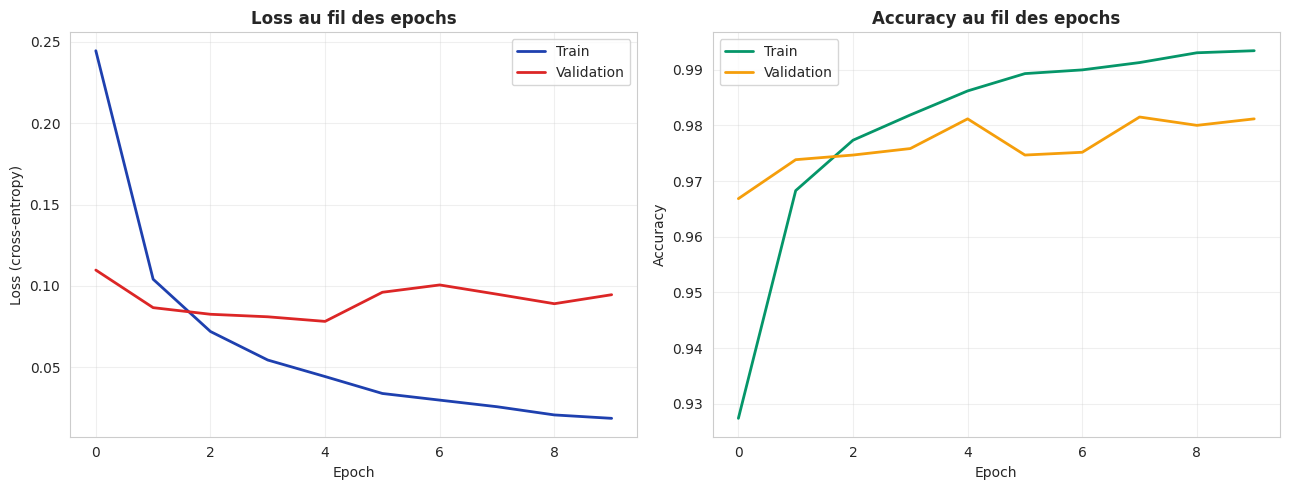

In [22]:
# ============================================================
# ÉTAPE 3B — Visualiser les courbes d'entraînement
# ============================================================
# POURQUOI : les courbes permettent de voir d'un coup d'œil si le modèle
#            apprend correctement ou s'il y a un problème :
#            - train_acc ≈ val_acc → bon modèle ✅
#            - train_acc >> val_acc → overfitting ⚠️
#            - les deux stagnent bas → underfitting ⚠️
# COMMENT  : on plotte loss et accuracy côte à côte pour train et validation

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Graphique 1 : Loss ─────────────────────────────────────
axes[0].plot(history.history['loss'],     label='Train',      linewidth=2, color='#1E40AF')
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2, color='#DC2626')
axes[0].set_title('Loss au fil des epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Graphique 2 : Accuracy ─────────────────────────────────
axes[1].plot(history.history['accuracy'],     label='Train',      linewidth=2, color='#059669')
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#F59E0B')
axes[1].set_title('Accuracy au fil des epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# ÉTAPE 4 — Évaluer sur le jeu de test
# ============================================================
# POURQUOI : le jeu de test n'a JAMAIS été vu pendant l'entraînement.
#            C'est la vraie mesure de performance du modèle dans le monde réel.
# COMMENT  : model.evaluate() calcule loss et accuracy sur le test.

test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  →  {test_acc*100:.2f}%")

# Sur MNIST, on attend ~97-98% d'accuracy avec ce modèle simple

Test Loss     : 0.0990
Test Accuracy : 0.9789  →  97.89%


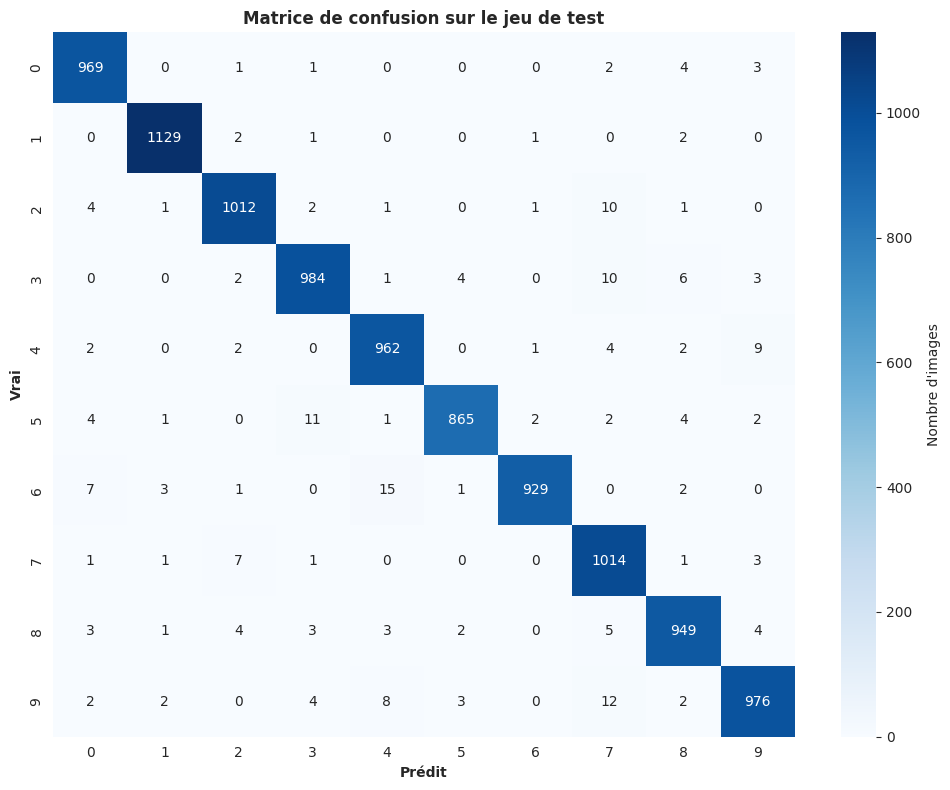

In [25]:
# ============================================================
# ÉTAPE 4B — Matrice de confusion
# ============================================================
# POURQUOI : l'accuracy globale (97%) ne dit pas QUELS chiffres sont mal
#            classés. La matrice de confusion montre EXACTEMENT quels
#            chiffres sont confondus entre eux (ex: 4 vs 9).
# COMMENT  : 1) on prédit les classes sur le test
#            2) on construit une matrice 10x10 (vrai × prédit)
#            3) on l'affiche en heatmap

# Prédictions : model.predict() donne les probabilités softmax (forme N×10)
y_prob = model.predict(x_test, verbose=0)
# argmax(axis=1) prend la classe avec la plus haute probabilité
y_pred = np.argmax(y_prob, axis=1)

# Matrice de confusion : ligne = vraie classe, colonne = classe prédite
# Diagonal = prédictions correctes, hors diagonale = erreurs
cm = confusion_matrix(y_test, y_pred)

# Visualisation en heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Nombre d\'images'})
plt.xlabel('Prédit', fontweight='bold')
plt.ylabel('Vrai', fontweight='bold')
plt.title('Matrice de confusion sur le jeu de test', fontweight='bold')
plt.tight_layout()
plt.show()

Accuracy par chiffre :
  Chiffre 0 : 98.88%
  Chiffre 1 : 99.47%
  Chiffre 2 : 98.06%
  Chiffre 3 : 97.43%
  Chiffre 4 : 97.96%
  Chiffre 5 : 96.97%
  Chiffre 6 : 96.97%
  Chiffre 7 : 98.64%
  Chiffre 8 : 97.43%
  Chiffre 9 : 96.73%

⚠️ Chiffre le plus difficile : 9 (96.73%)

Rapport détaillé :
              precision    recall  f1-score   support

           0     0.9768    0.9888    0.9828       980
           1     0.9921    0.9947    0.9934      1135
           2     0.9816    0.9806    0.9811      1032
           3     0.9772    0.9743    0.9757      1010
           4     0.9707    0.9796    0.9752       982
           5     0.9886    0.9697    0.9791       892
           6     0.9946    0.9697    0.9820       958
           7     0.9575    0.9864    0.9717      1028
           8     0.9753    0.9743    0.9748       974
           9     0.9760    0.9673    0.9716      1009

    accuracy                         0.9789     10000
   macro avg     0.9790    0.9785    0.9787     10000


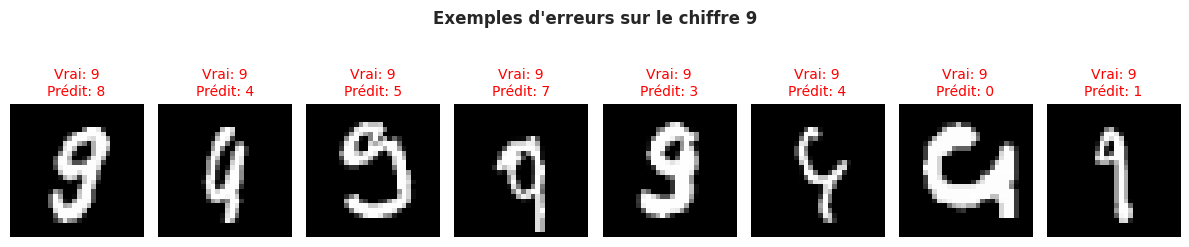

In [26]:
# ============================================================
# ÉTAPE 4C — Identifier les chiffres les plus difficiles
# ============================================================
# POURQUOI : pour améliorer le modèle, il faut savoir où il échoue.
#            Certains chiffres sont visuellement proches (4↔9, 3↔8, 7↔1).
# COMMENT  : on calcule l'accuracy par classe = diagonale / somme de la ligne

# Accuracy par chiffre = bonnes prédictions de cette classe / total de cette classe
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print("Accuracy par chiffre :")
for digit in range(10):
    print(f"  Chiffre {digit} : {per_class_acc[digit]*100:.2f}%")

# Chiffre le plus difficile
worst = per_class_acc.argmin()
print(f"\n⚠️ Chiffre le plus difficile : {worst} ({per_class_acc[worst]*100:.2f}%)")

# Rapport complet (precision, recall, f1 par classe)
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred, digits=4))

# Quelques exemples mal classés du chiffre le plus difficile
errors = (y_test == worst) & (y_pred != worst)
error_indices = np.where(errors)[0][:8]

if len(error_indices) > 0:
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(error_indices):
        plt.subplot(1, 8, i+1)
        plt.imshow(x_test[idx], cmap='gray')
        plt.title(f"Vrai: {y_test[idx]}\nPrédit: {y_pred[idx]}",
                  color='red', fontsize=10)
        plt.axis('off')
    plt.suptitle(f"Exemples d'erreurs sur le chiffre {worst}", fontweight='bold')
    plt.tight_layout()
    plt.show()

# 🎯 Interprétation des résultats — Mon réseau neuronal sur MNIST

## 📊 Résultats finaux

| Métrique | Train | Validation | Test |
|---|---|---|---|
| **Loss** | 0.0187 | 0.0946 | 0.0990 |
| **Accuracy** | 99.34% | 98.12% | **97.89%** |

> 🎉 **Performance globale : 97.89% sur 10 000 images de test** → soit **9 789 chiffres correctement classés** sur 10 000. Excellent résultat pour un réseau dense simple en seulement 10 epochs !

---

## 🧠 Lecture détaillée des courbes d'entraînement

### Courbe de Loss

**Ce que j'observe :**
- La loss d'entraînement chute brutalement de **0.24 à 0.10** dès la 1ère epoch
- Elle continue à descendre jusqu'à **0.019** à l'epoch 10
- La loss de validation stagne autour de **0.08-0.10** dès l'epoch 2
- À partir de l'epoch 5, la **val_loss remonte légèrement** (0.078 → 0.095)

**Diagnostic : début de sur-apprentissage léger**

L'écart entre train_loss (0.019) et val_loss (0.095) atteint un facteur ×5. C'est le signe classique que le modèle commence à **mémoriser** des détails du train qui ne généralisent pas. Cependant, l'écart reste **maîtrisé** — le test accuracy à 97.89% le confirme.

### Courbe d'Accuracy

**Ce que j'observe :**
- Train accuracy monte de **92.8% à 99.34%** (gain de +6.5 points)
- Validation accuracy monte de **96.7% à 98.12%** (gain de +1.4 points)
- L'écart final entre train (99.34%) et val (98.12%) est de **1.22 points**

**Diagnostic :**
- Le modèle a **bien appris** (train très haut)
- Il **généralise bien** (val proche du train)
- L'écart de 1.22 points est **acceptable** pour ce type de réseau

> 💡 **Interprétation** : on aurait pu arrêter l'entraînement vers **epoch 4-5** (early stopping) sans perdre en performance test, en évitant le léger sur-apprentissage.

---

## 🔍 Analyse de la matrice de confusion

### Forces du modèle ⭐

Les classes **les mieux reconnues** :
- **Chiffre 1** : 99.47% (1129/1135 correctes)
- **Chiffre 0** : 98.88% (969/980)
- **Chiffre 6** : 96.97% (929/958)

Le **1** est si bien reconnu car sa forme simple (un trait vertical) le rend très distinctif. Le **0** a une boucle fermée caractéristique.

### Faiblesses du modèle ⚠️

Les classes **les plus difficiles** :
- **Chiffre 9** : 96.73% (976/1009) → 33 erreurs ❌ **Le plus difficile**
- **Chiffre 5** : 96.97% (865/892) → 27 erreurs
- **Chiffre 8** : 97.43% (949/974) → 25 erreurs

### Confusions principales identifiées

D'après la matrice :

| Vrai → Prédit | Erreurs | Raison probable |
|---|---|---|
| **5 → 3** | 11 | Boucle inférieure similaire |
| **6 → 4** | 15 | Confusion étrange — à investiguer |
| **9 → 7** | 12 | Trait diagonal similaire |
| **9 → 4** | 8 | Le haut peut être ambigu |
| **3 → 5/7** | 10/10 | Formes courbes proches |
| **4 → 9** | 9 | Inverse de l'erreur 9→4 |
| **2 → 7** | 10 | Quand le 2 est tracé sans boucle |

> 🎯 **Insight clé** : les confusions sont **réciproques** (4↔9, 5↔3) et correspondent à des chiffres réellement ambigus à l'écriture manuscrite. C'est un comportement attendu.

---

## 🚨 Focus sur le chiffre 9 (le plus difficile)

### Pourquoi le 9 est-il problématique ?

En regardant les **8 exemples d'erreurs** affichés :
- Plusieurs **9 ressemblent fortement à des 4** (style d'écriture avec le haut ouvert)
- Certains sont **mal écrits** ou ambigus même pour un humain
- Un 9 a été confondu avec 0, 1, 3, 4, 5, 7, 8 → toutes les confusions possibles !

### Ce que ça nous dit

Le modèle a appris une **représentation correcte du 9** mais il est sensible aux **variations stylistiques** :
- 9 avec le haut très arrondi → ressemble à 0
- 9 avec un trait diagonal accentué → ressemble à 4 ou 7
- 9 mal formé ou tronqué → peut ressembler à n'importe quoi

> 💡 **Pour améliorer** : une **augmentation de données** (rotations légères, déformations élastiques) entraînerait le modèle à reconnaître le 9 sous plus de formes.

---

## 🏆 Pourquoi ces choix de modèle ?

### Architecture : Flatten → Dense(128) → Dense(64) → Dense(10)

**Pourquoi cette structure marche bien ici ?**

1. **Flatten** : MNIST n'a besoin que de la valeur de chaque pixel, pas de structure spatiale (pour MNIST simple, les positions absolues suffisent)

2. **128 → 64 (entonnoir)** :
   - 128 neurones = assez pour capturer les **motifs basiques** (bords, courbes)
   - 64 neurones = force le réseau à **résumer** ces motifs
   - Cette compression réduit le sur-apprentissage

3. **ReLU** : choix robuste, calcul rapide, pas de saturation

4. **Softmax(10)** : transforme les scores en probabilités → permet d'interpréter "le modèle est sûr à 95% que c'est un 3"

### Optimiseur Adam : pourquoi il a si bien marché ?

- Adam ajuste **automatiquement** le learning rate pour chaque poids
- Il **converge vite** : la loss chute de 0.24 à 0.10 en 1 seule epoch !
- Pas besoin de tuning manuel du learning rate

### Cross-entropy : la loss adaptée

- Mesure la **distance entre probabilités**
- Pénalise fortement les **prédictions confiantes ET fausses**
- Force le réseau à être **prudent**

---
